        ┌───┐┌───┐ ░ ┌─┐
     q: ┤ H ├┤ X ├─░─┤M├
        └───┘└───┘ ░ └╥┘
   c: 1/══════════════╬═
                      ║ 
meas: 1/══════════════╩═
                      0 


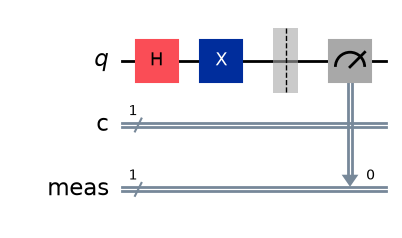

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.x(0)
# qc.measure(0 , 0)  
# BEING SPECIFIC
qc.measure_all()


print(qc.draw())
display(qc.draw(output = "mpl"))

{'0': 505, '1': 495}


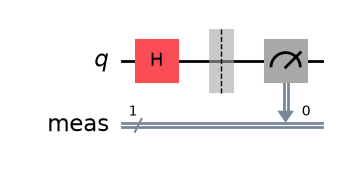

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1)
qc.h(0)
# qc.measure(0, 0)
qc.measure_all()

sm = AerSimulator()

cc = transpile(qc, sm)

job = sm.run(cc , shots = 1000)

result = job.result()

counts = result.get_counts(qc)
print(counts)

display(qc.draw(output = "mpl"))

┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ X ├┤ H ├─░─┤M├───
        ├───┤└───┘ ░ └╥┘┌─┐
   q_1: ┤ H ├──────░──╫─┤M├
        └───┘      ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

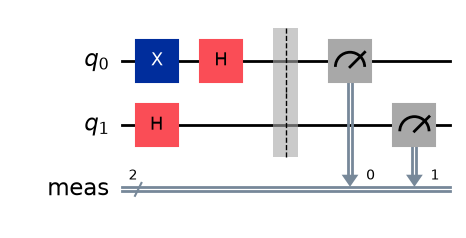

{'00': 2475, '11': 2577, '10': 2477, '01': 2471}


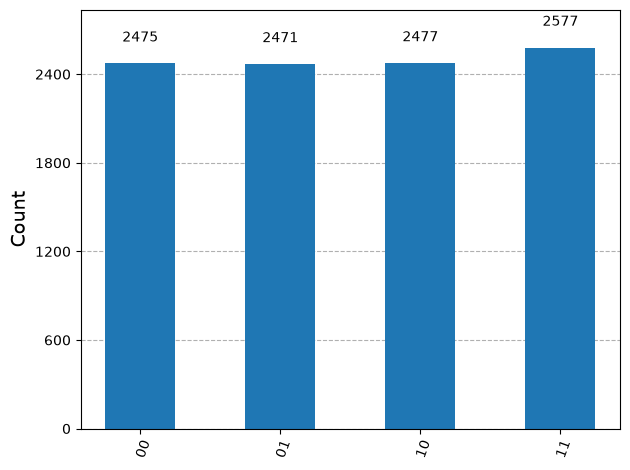

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(2)
qc.x(0)
qc.h(0)
qc.h(1)
qc.measure_all()

# sm = AerSimulator()
sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)

job = sm.run(ts, shots = 10000)

res = job.result()

counts = res.get_counts(qc)

display(qc.draw())
display(qc.draw(output = "mpl"))
print(counts)
plot_histogram(counts)

{'01': 495, '00': 505}
        ┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ H ├┤ X ├─░─┤M├───
        └───┘└───┘ ░ └╥┘┌─┐
   q_1: ───────────░──╫─┤M├
                   ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


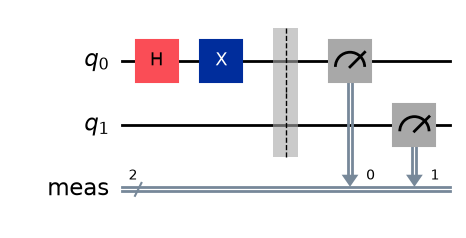

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer  

qc = QuantumCircuit(2)
qc.h(0)
qc.x(0)

qc.measure_all()

sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)

job = sm.run(ts, shots = 1000)

res = job.result()

cnts = res.get_counts(qc)

print(cnts)
print(qc.draw())
display(qc.draw(output = "mpl"))

Statevector([ 0.        +0.j, -0.        +0.j,  0.70710678+0.j,
              0.70710678+0.j],
            dims=(2, 2))
[0.  0.  0.5 0.5]
{np.str_('10'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


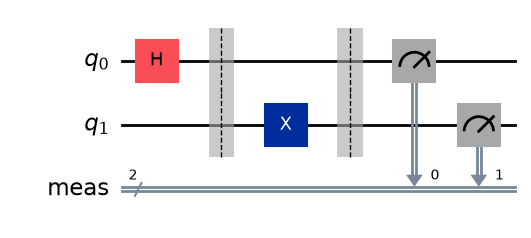

Result(backend_name='qasm_simulator', backend_version='0.17.2', job_id='2a70a5d0-112e-444e-8bbb-1d1a25a3b681', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x2': 499, '0x3': 501}), header={'creg_sizes': [['meas', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 2, 'name': 'circuit-53', 'qreg_sizes': [['q', 2]], 'metadata': {}}, status=DONE, seed_simulator=183754966, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0033698, 'sample_measure_time': 0.0015903, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 7913, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 12, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.0033698)], date=2026-09-20T15:35:12.0

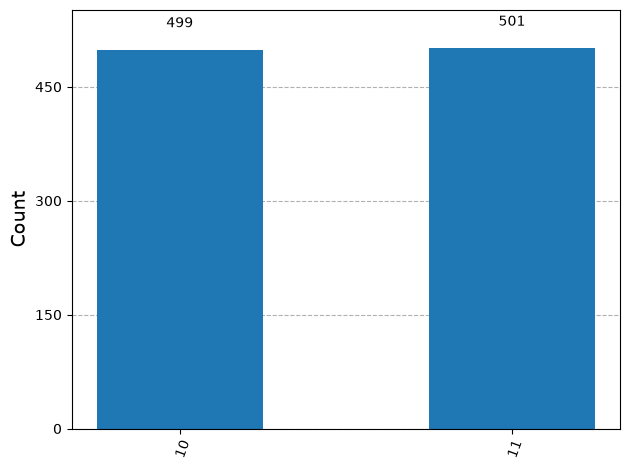

In [5]:
from qiskit import QuantumCircuit, transpile 
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer


qc = QuantumCircuit(2)
qc.h(0)
qc.barrier()
qc.x(1)

# qc.measure_all()
# display(qc.draw("mpl"))

v = Statevector.from_instruction(qc)
print(v)
print(v.probabilities())
print(v.probabilities_dict())

qc.measure_all()
display(qc.draw("mpl"))

sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)
job = sm.run(ts, shots = 1000)
rlt = job.result()
print(rlt)
print(rlt.get_counts(qc))

plot_histogram(rlt.get_counts(qc))

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
[0. 1.]
{np.str_('1'): np.float64(0.9999999999999996)}


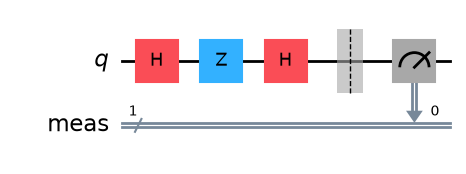

{'1': 1000}


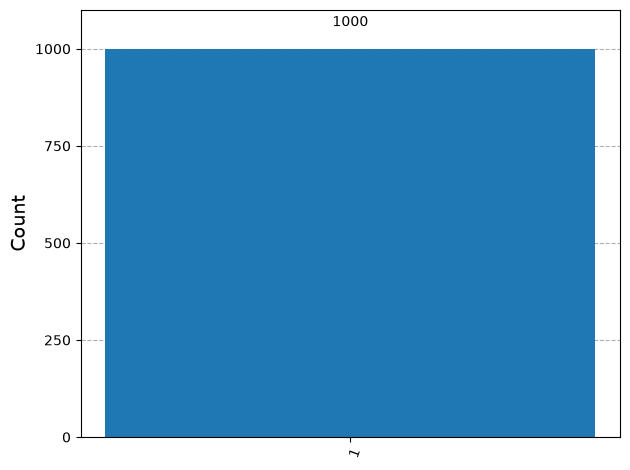

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

qs = QuantumCircuit(1)

qs.h(0)
qs.z(0)
qs.h(0)

vtr = Statevector.from_instruction(qs)
print(vtr)
print(vtr.probabilities())
print(vtr.probabilities_dict())

qs.measure_all()
sm = Aer.get_backend("qasm_simulator")
tc = transpile(qs , sm)
job = sm.run(tc , shots = 1000)
rs = job.result()

cnts = rs.get_counts(qs)

display(qs.draw("mpl"))
print(cnts)
display(plot_histogram(cnts))

Statevector([ 0.+0.00000000e+00j, -1.-6.22328532e-19j],
            dims=(2,))
{np.str_('1'): np.float64(0.9999999999999993)}


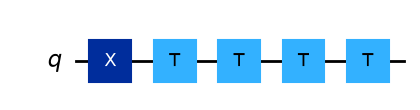

In [7]:
qc = QuantumCircuit(1)

# Prepare |1>
qc.x(0)

qc.t(0)
qc.t(0)
qc.t(0)
qc.t(0)

state = Statevector.from_instruction(qc)

print(state)
print(state.probabilities_dict())

display(qc.draw("mpl"))

Statevector([ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
            dims=(2, 2))
{np.str_('11'): np.float64(1.0)}


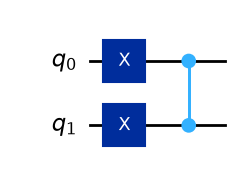

In [8]:
qc = QuantumCircuit(2)

# Prepare |11>
qc.x(0)
qc.x(1)

qc.cz(0, 1)

state = Statevector.from_instruction(qc)

print(state)
print(state.probabilities_dict())

display(qc.draw("mpl"))

Before SWAP:
{np.str_('01'): np.float64(1.0)}
After SWAP:
Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))
{np.str_('10'): np.float64(1.0)}


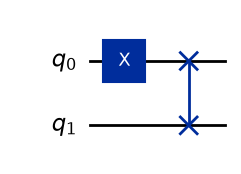

In [9]:
qc = QuantumCircuit(2)

# q0 = 1, q1 = 0
qc.x(0)

print("Before SWAP:")
print(Statevector.from_instruction(qc).probabilities_dict())

qc.swap(0, 1)

state = Statevector.from_instruction(qc)

print("After SWAP:")
print(state)
print(state.probabilities_dict())

display(qc.draw("mpl"))

Before:
{np.str_('101'): np.float64(1.0)}
After:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))
{np.str_('011'): np.float64(1.0)}


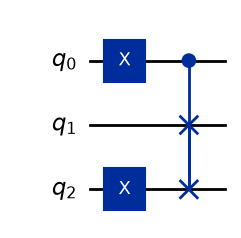

In [10]:
qc = QuantumCircuit(3)

# control q0 = 1
qc.x(0)

# q1 = 0

# q2 = 1
qc.x(2)

print("Before:")
print(Statevector.from_instruction(qc).probabilities_dict())

# q0 controls the swap of q1 and q2
qc.cswap(0, 1, 2)

state = Statevector.from_instruction(qc)

print("After:")
print(state)
print(state.probabilities_dict())

display(qc.draw("mpl"))

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2, 2, 2, 2))


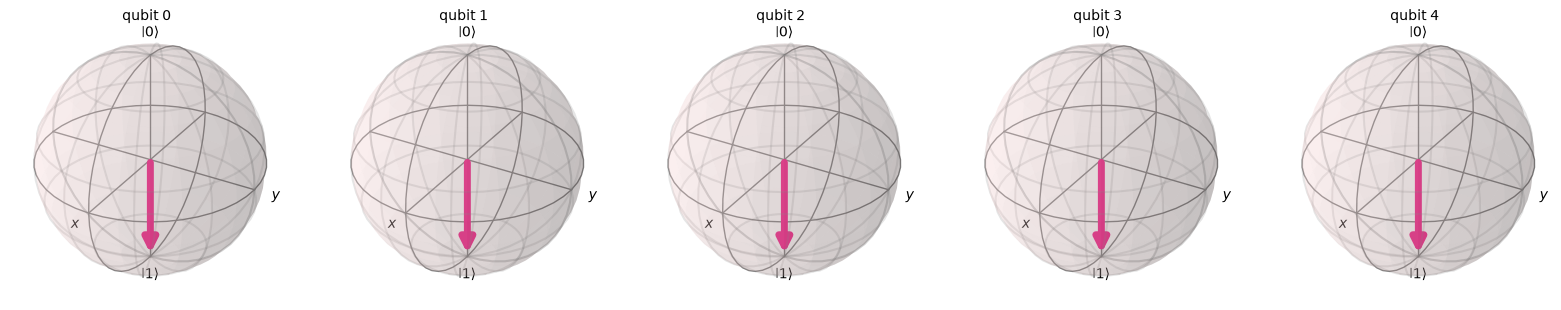

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1.]
{np.str_('11111'): np.float64(1.0)}
{'11': 1000}


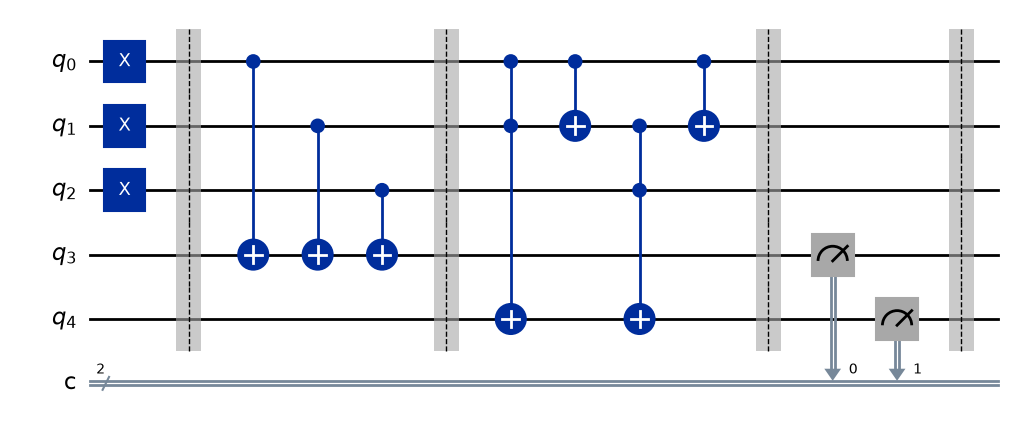

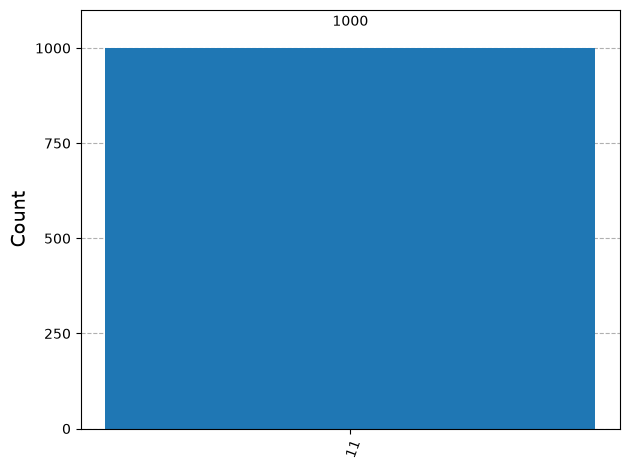

In [ ]:
from qiskit import QuantumCircuit, transpile 
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import Aer


qc = QuantumCircuit(5 , 2)

qc.x(0) # A
qc.x(1) # B
qc.x(2) # C
qc.barrier()

qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(2, 3)
qc.barrier()


qc.ccx(0 , 1, 4)
qc.cx(0 , 1)
qc.ccx(1 , 2 , 4)
qc.cx(0 , 1)
qc.barrier()


vtr = Statevector.from_instruction(qc)
print(vtr)
display(plot_bloch_multivector(vtr))
print(vtr.probabilities())
print(vtr.probabilities_dict())

qc.measure(3 , 0)
qc.measure(4 , 1)
qc.barrier()

sm = Aer.get_backend("qasm_simulator")
tc = transpile(qc, sm)

rs = sm.run(tc, shots = 1000).result()
counts = rs.get_counts(qc)

print(counts)
display(qc.draw("mpl"))
display(plot_histogram(counts))

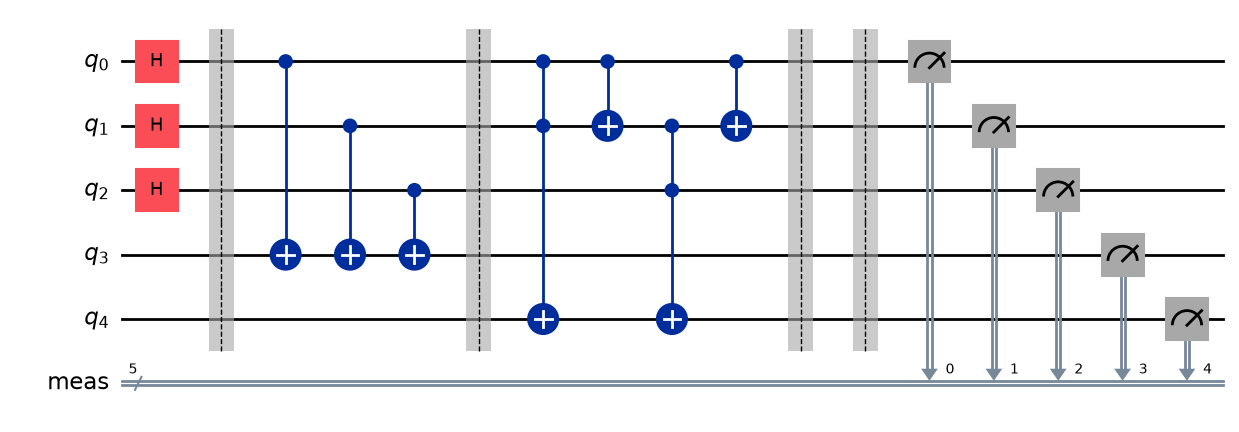

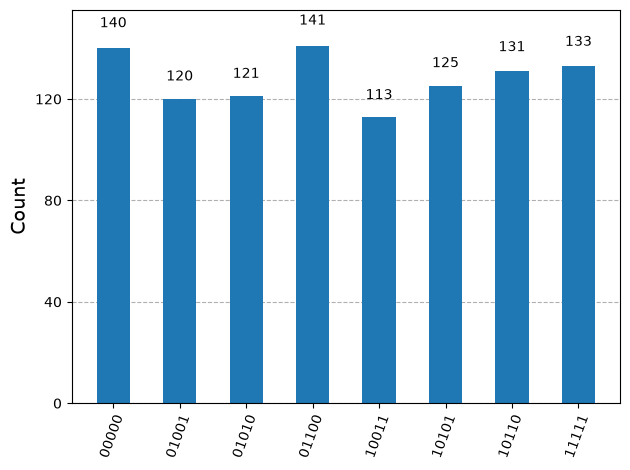

{'10011': 113, '00000': 140, '10101': 125, '01001': 120, '01010': 121, '01100': 141, '11111': 133, '10110': 131}


In [5]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt


# Create circuit: 5 qubits, 2 classical bits
# q0 = A
# q1 = B
# q2 = Cin
# q3 = Sum
# q4 = Carry

qc = QuantumCircuit(5)


# Put input qubits q0, q1, q2 in superposition
# to generate all input combinations

qc.h(0)
qc.h(1)
qc.h(2)

qc.barrier()


# -------------------------------------------------
# SUM
# q3 = A XOR B XOR Cin
# -------------------------------------------------

qc.cx(0, 3)      # q3 = A
qc.cx(1, 3)      # q3 = A XOR B
qc.cx(2, 3)      # q3 = A XOR B XOR Cin

qc.barrier()


# -------------------------------------------------
# CARRY
# q4 = Carry
# -------------------------------------------------

qc.ccx(0, 1, 4)      # Carry from A AND B

qc.cx(0, 1)           # temporary: A XOR B in q1

qc.ccx(1, 2, 4)      # Carry from (A XOR B) AND Cin

qc.cx(0, 1)           # restore original B

qc.barrier()


# -------------------------------------------------
# Measure Sum and Carry
# -------------------------------------------------

qc.measure_all()

# -------------------------------------------------
# Draw circuit
# -------------------------------------------------

display(qc.draw(output="mpl"))


# -------------------------------------------------
# Run simulation
# -------------------------------------------------

simulator = Aer.get_backend("qasm_simulator")

compiled_circuit = transpile(qc, simulator)

result = simulator.run(
    compiled_circuit,
    shots=1024
).result()

counts = result.get_counts()


# -------------------------------------------------
# Plot results
# -------------------------------------------------

display(plot_histogram(counts))

print(counts)


Constant


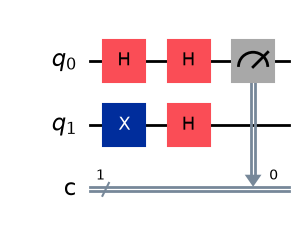

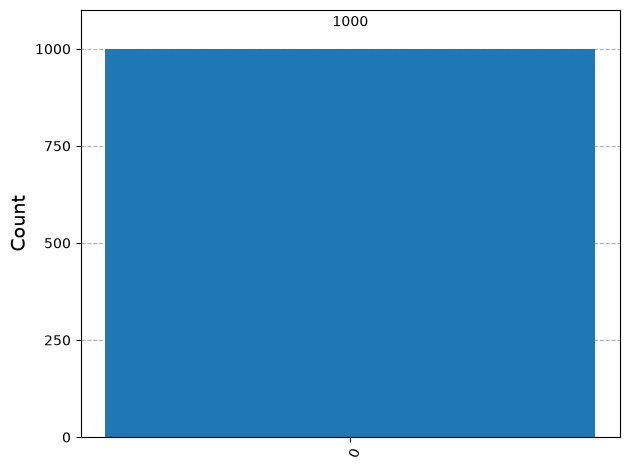

In [24]:
from qiskit import QuantumCircuit, transpile 
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

def oracle(x):
    qc = QuantumCircuit(2)

    if x == "constant1": qc.x(1)
    elif x == "balanced01": qc.cx(0 , 1)
    elif x == "balanced10":
        qc.x(1)
        qc.cx(0, 1)
    return qc

def algo(x):
    qc = QuantumCircuit(2 ,1)
    qc.x(1)
    qc.h([0 , 1])
    qc.compose(oracle(x), inplace=True)
    qc.h(0)
    qc.measure(0 , 0)
    return qc

qc = algo("balanced1")
sm = Aer.get_backend("qasm_simulator")
tc = transpile(qc, sm)

rslt = sm.run(tc, shots = 1000).result()
cnts = rslt.get_counts(qc)

if '0' in cnts and cnts['0'] > cnts.get('1' , 0):
    print("Constant")
else:
    print("Balanced")

display(qc.draw("mpl"))
plot_histogram(cnts)

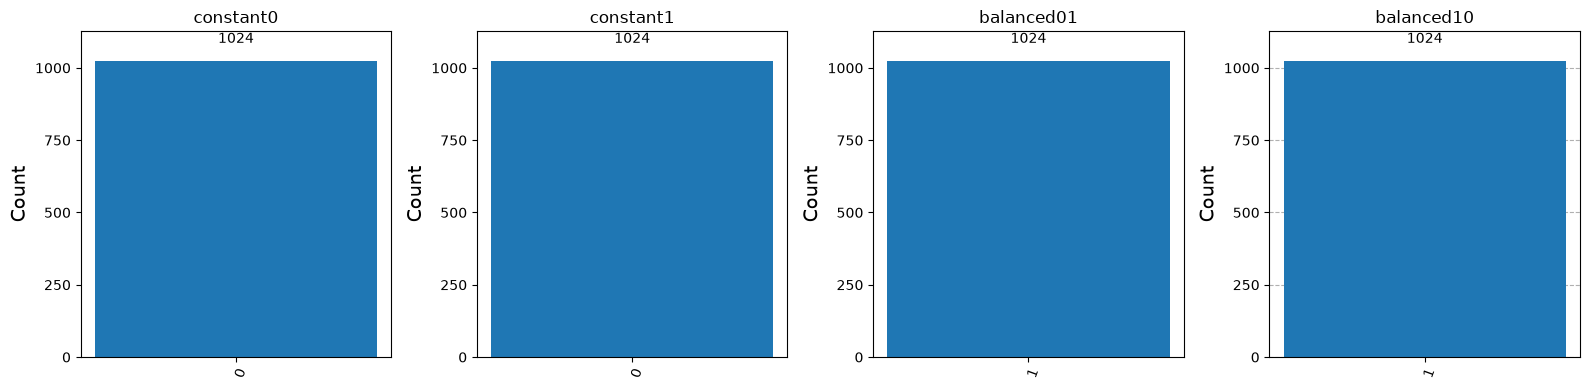

In [50]:
def oracle(x):
    qc = QuantumCircuit(2)
    if x == "constant1": qc.x(1)
    elif x == "balanced01": qc.cx(0 , 1)
    elif x == "balanced10":
        qc.x(1)
        qc.cx(0, 1)
    return qc

def algo(x):
    qc = QuantumCircuit(2 , 1)
    qc.x(1)
    qc.h([0 , 1])
    qc.compose(oracle(x), inplace= True)
    qc.h(0)
    qc.measure(0 , 0)
    return qc

types = ["constant0", "constant1", "balanced01", "balanced10"]
rslts = {}

for x in types:
    qs = algo(x)
    sm = Aer.get_backend("qasm_simulator")
    ts = transpile(qs, sm)
    rslts[x] = sm.run(ts, shots = 1024).result().get_counts(qs)

import matplotlib.pyplot as plt

_ , ax = plt.subplots(1 , 4, figsize = (16 , 4))
for x , y in zip(ax, types):
    plot_histogram(rslts[y], ax = x)
    x.set_title(y)

plt.tight_layout()
plt.show()

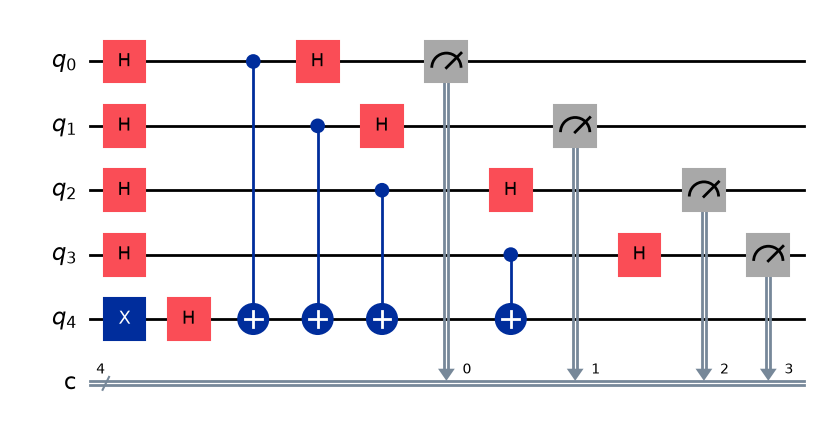

{'1111': 1024}


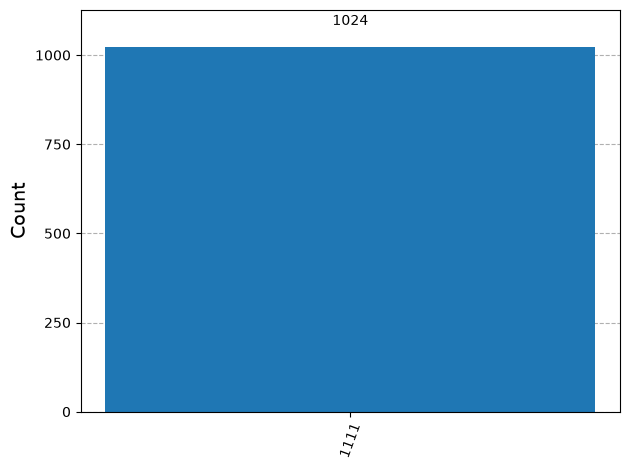

Balanced


In [ ]:
import random
def constant0(n):
    qc = QuantumCircuit(n + 1)
    return qc

def constant1(n):
    qc = QuantumCircuit(n + 1)
    qc.x(n)
    return qc

def balanced(n):
    qc = QuantumCircuit(n + 1)
    for x in range(n):
        qc.cx(x , n)
    return qc 

n = 4

types = ["constant0", "constant1", "balanced"]
choice = random.choice(types)

if choice == "constant0": ch = constant0(n)
elif choice == "constant1": ch = constant1(n)
else: ch = balanced(n)

qc = QuantumCircuit(n + 1, n)
qc.x(n)
qc.h(range(n + 1))
qc.compose(ch, inplace=True)
qc.h(range(n))
qc.measure(range(n), range(n))

display(qc.draw("mpl"))

sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)
rlt = sm.run(ts, shots = 1024).result().get_counts(qc)
print(rlt)
display(plot_histogram(rlt))

if "0"*n in rlt and rlt["0"*n] == 1024:
    print("Constant")
else:
    print("Balanced")

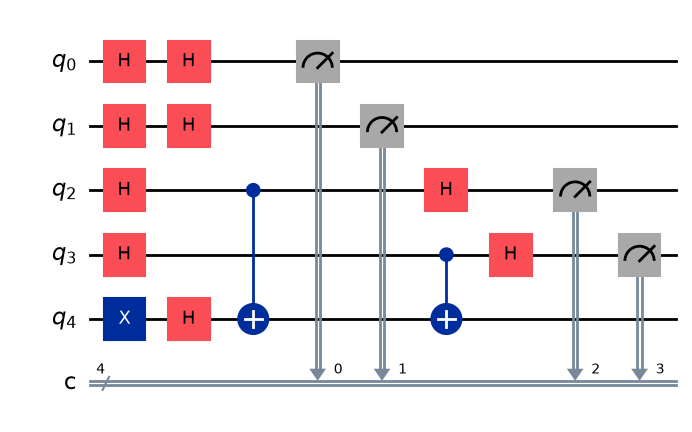

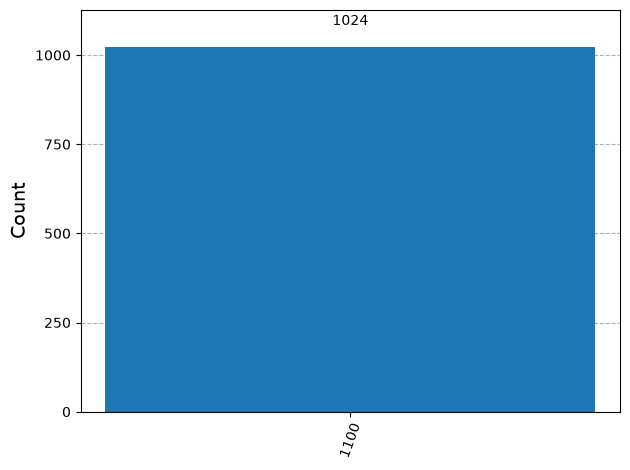

1100


In [62]:
n  = 4

s = ''.join([str(random.randint(0,1)) for _ in range(n)])

def oracle(s):
    m = len(s)
    qc = QuantumCircuit(m + 1)
    for i , c in enumerate(reversed(s)):
        if c == "1":
            qc.cx(i , n)
    return qc

orc = oracle(s)

qc = QuantumCircuit(n + 1, n)
qc.x(n)
qc.h(range(n + 1))
qc.compose(orc, inplace=True)
qc.h(range(n))
qc.measure(range(n), range(n))

sm = Aer.get_backend("qasm_simulator")
tc = transpile(qc , sm)
r = sm.run(tc , shots = 1024).result().get_counts()

display(qc.draw("mpl"))
display(plot_histogram(r))

maxa = max(r , key=r.get)
print(maxa)